## Imports

In [256]:
import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.measure import label, regionprops
from scipy.ndimage import label as cc_label

plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

## Helpers

In [257]:

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : int or iterable of ints — GMM component(s) to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    cluster_ids = np.atleast_1d(cluster_id)
    sel = np.isin(gmm_labels, cluster_ids)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])

    return blobs, labeled

In [258]:
def make_samples(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses raw E (no log) as the third feature.

    Returns:
      X_raw : (N,3) with columns [y, x, E]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    X_raw = np.column_stack([ys, xs, E])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

Fit GMM

In [259]:
REG_COVAR = 1e-6
RANDOM_STATE = 209

def fit_gmms_over_K(X_raw, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE):
    """
    Standardize features, fit a full-covariance GMM for each K.
    Returns: list of dicts with model, labels, BIC, AIC.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_raw)

    results = []
    for K in K_RANGE:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            reg_covar=reg_covar,
            random_state=random_state
        )
        gmm.fit(X_std)

        labels = gmm.predict(X_std)

        bic = gmm.bic(X_std)
        aic = gmm.aic(X_std)
        results.append({
            "K": K,
            "model": gmm,
            "labels": labels,
            "bic": bic,
            "aic": aic,
        })

    results.sort(key=lambda r: r["bic"])
    return results

Plotting options

In [260]:
from matplotlib.colors import ListedColormap

def plot_fullframe_clusters(idx_yx, labels, frame_size=(320, 640), title=None):
    H, W = frame_size
    y = idx_yx[:, 0]
    x = idx_yx[:, 1]

    # ---- Build image storing cluster labels ----
    img = np.full((H, W), -1, dtype=int)
    img[y, x] = labels

    # ---- Define colors ----
    dark_pink  = [0.80, 0.10, 0.45, 1.0]   # strong pink/magenta
    light_blue = [0.45, 0.75, 0.95, 1.0]   # clear light blue

    colors = np.vstack([
        [1, 1, 1, 1],     # background = white
        light_blue,       # cluster 0
        dark_pink         # cluster 1
    ])

    cmap = ListedColormap(colors)

    img_plot = img + 1  # shift background (-1) → 0

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(24, 4))
    ax.imshow(img_plot, origin='lower', cmap=cmap, interpolation='none')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("Column index (x)")
    ax.set_ylabel("Row index (y)")
    ax.set_title(title if title else "GMM clusters (full frame)")

    plt.tight_layout()
    plt.show()



In [261]:
from matplotlib.colors import ListedColormap

def plot_one_cluster(idx_yx, result, ccd_shape, cluster_id, origin="lower"):
    """
    imshow-style plot (like your example) but only for a single cluster_id.
    """
    H, W = ccd_shape
    labels = np.asarray(result["labels"])

    # pick points for this cluster
    sel = (labels == cluster_id)
    ys = np.asarray(idx_yx[:, 0], dtype=int)[sel]
    xs = np.asarray(idx_yx[:, 1], dtype=int)[sel]

    # make a 0/1 image for this cluster only
    img = np.zeros((H, W), dtype=np.uint8)
    img[ys, xs] = 1

    # colormap: background white, cluster blue (change if you want)
    cmap = ListedColormap(["white", "#1f77b4"])

    plt.figure(figsize=(24, 4))
    plt.imshow(img, origin=origin, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"GMM Cluster {cluster_id}")
    plt.xlabel("Column index (x)")
    plt.ylabel("Row index (y)")
    plt.tight_layout()
    plt.show()


In [262]:
def plot_cluster_gallery_on_frame(idx_yx, result, ccd_shape, max_points_per_cluster=None,
                                   panel_width=20):
    """
    Plot the cluster gallery for a single (best) result.
    Each panel shows the FULL CCD frame, with only that cluster overplotted.
    Panels are stacked vertically.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    max_points_per_cluster : optional cap on points per cluster
    panel_width : width in inches of each panel (height is set by CCD aspect ratio)
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    panel_height = panel_width * H / W  # match CCD aspect ratio

    fig, axes = plt.subplots(
        K, 1,
        figsize=(panel_width, panel_height * K),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — full-frame view", y=1.0)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k][0]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        ax.scatter(x_all[sel], y_all[sel], s=2)

        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_aspect("equal", "box")

        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    plt.tight_layout()
    plt.show()

In [263]:
def plot_clusters_on_frame(idx_yx, result, ccd_shape, clusters_to_show=None,
                            max_points_per_cluster=None, cmap_name="tab10",
                            figsize=(8, 8), point_size=2,
                            xlim=None, ylim=None):
    """
    Plot selected clusters on a single full CCD frame, each in a different color.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    clusters_to_show : iterable of cluster indices to plot (e.g. [0, 1, 2, 3]).
        If None, all clusters are shown.
    max_points_per_cluster : optional cap on points per cluster
    cmap_name : matplotlib colormap name (qualitative recommended)
    xlim : (xmin, xmax) tuple to zoom into a column range. If None, full width.
    ylim : (ymin, ymax) tuple to zoom into a row range. If None, full height.
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    if clusters_to_show is None:
        clusters_to_show = list(range(K))
    else:
        clusters_to_show = list(clusters_to_show)
        bad = [k for k in clusters_to_show if k < 0 or k >= K]
        if bad:
            raise ValueError(f"Invalid cluster indices {bad}; valid range is 0..{K-1}")

    cmap = plt.get_cmap(cmap_name)
    rng = np.random.default_rng(209)

    fig, ax = plt.subplots(figsize=figsize)

    for i, k in enumerate(clusters_to_show):
        sel = (labels == k)
        if not sel.any():
            continue

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        color = cmap(i % cmap.N)
        ax.scatter(x_all[sel], y_all[sel], s=point_size,
                   color=color, label=f"Cluster {k}")

    ax.set_xlim(xlim if xlim is not None else (0, W))
    ax.set_ylim(ylim if ylim is not None else (0, H))
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x (col)")
    ax.set_ylabel("y (row)")
    title = f"GMM clusters (showing {len(clusters_to_show)} of K={K})"
    if xlim is not None or ylim is not None:
        title += f"  [zoom: x={xlim}, y={ylim}]"
    ax.set_title(title)

    leg = ax.legend(markerscale=4, loc="upper left", bbox_to_anchor=(1.01, 1), framealpha=0.9)
    for handle in leg.legend_handles:
        handle.set_sizes([30])

    plt.tight_layout()
    plt.show()

## Pull waders calibrated image

In [264]:
fits_path = "/Users/salms/damicm-ml/img_8_stuff/sample1/avg_Image_8_Low_Temp_106_20250923_093303_0_extD_waders.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

Filename: /Users/salms/damicm-ml/img_8_stuff/sample1/avg_Image_8_Low_Temp_106_20250923_093303_0_extD_waders.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  CALIBRATED    1 PrimaryHDU     157   (3500, 500)   float64   
  1  PEDSUBTRACTED    1 ImageHDU         8   (3500, 500)   float64   
  2  MEAN          1 ImageHDU         8   (3500, 500)   float64   
  3  FULLMASK      1 ImageHDU         8   (3500, 500)   float64   
  4  CLSMASK       1 ImageHDU         8   (3500, 500)   float64   


In [265]:
with fits.open(fits_path) as hdul:
    cal_img = hdul[0].data

In [266]:
print("shape:", cal_img.shape)
print("type:", type(cal_img))
print("dtype:", cal_img.dtype)

shape: (500, 3500)
type: <class 'numpy.ndarray'>
dtype: >f8


In [267]:
# convert image from calibration into electron into keV
cal_img = (cal_img * 3.74)/1000  # e- to keV

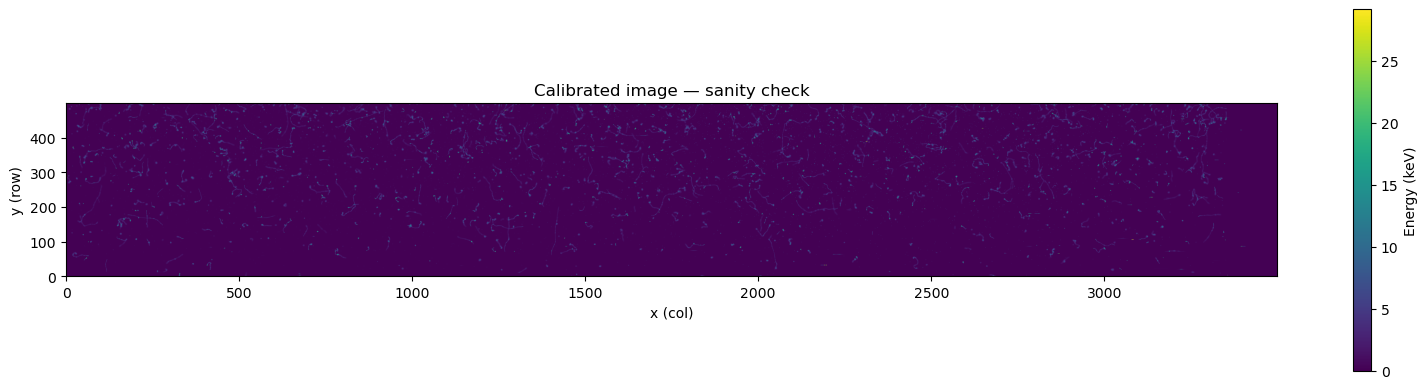

In [268]:
plt.figure(figsize=(16, 4))
im = plt.imshow(cal_img, origin="lower", cmap="viridis")
cbar = plt.colorbar(im)
cbar.set_label("Energy (keV)")
plt.xlabel("x (col)")
plt.ylabel("y (row)")
plt.title("Calibrated image — sanity check")
plt.tight_layout()
plt.show()

## GMM analysis

In [269]:
K_RANGE = [2]

In [270]:
# build samples
X_raw_cut, idx_yx = make_samples(cal_img)

In [271]:
results_cut = fit_gmms_over_K(X_raw_cut, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE)

In [272]:
best = results_cut[0]

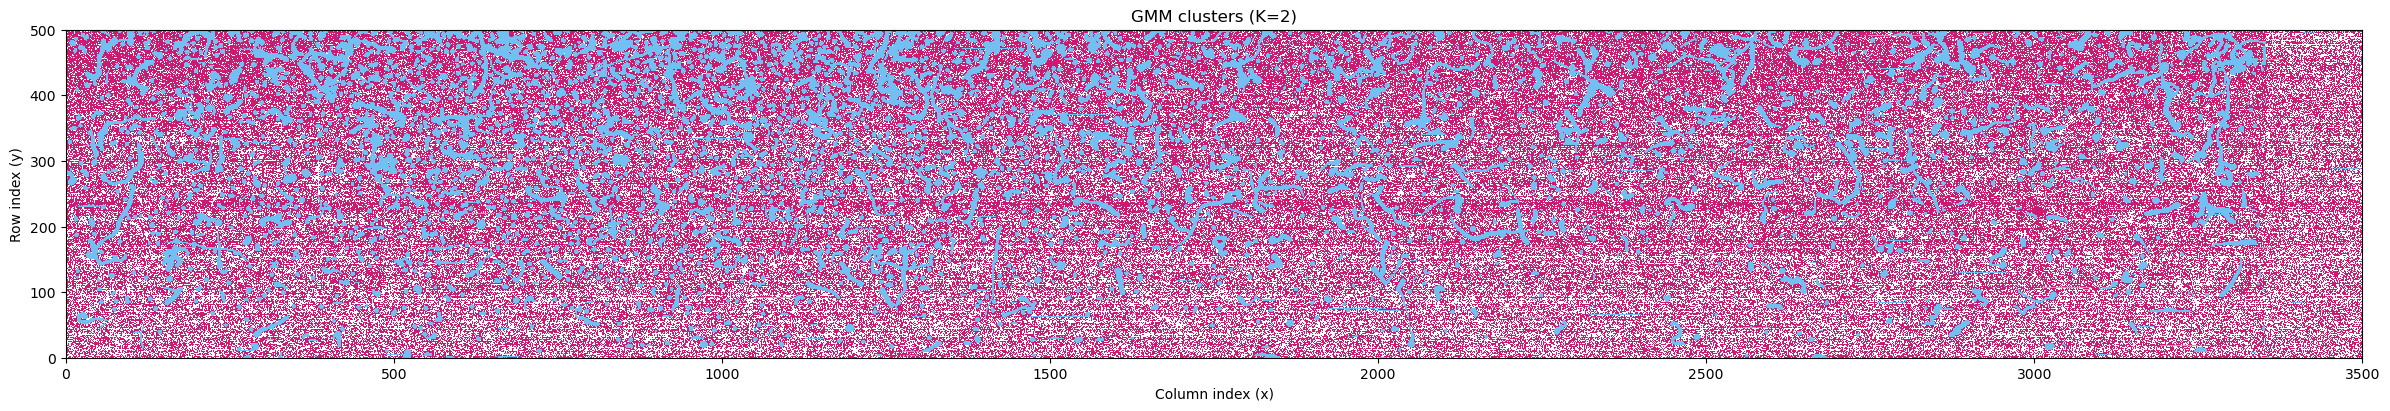

In [273]:
plot_fullframe_clusters(
    idx_yx,
    best["labels"],
    frame_size=cal_img.shape,
    title=f"GMM clusters (K={best['K']})"
)

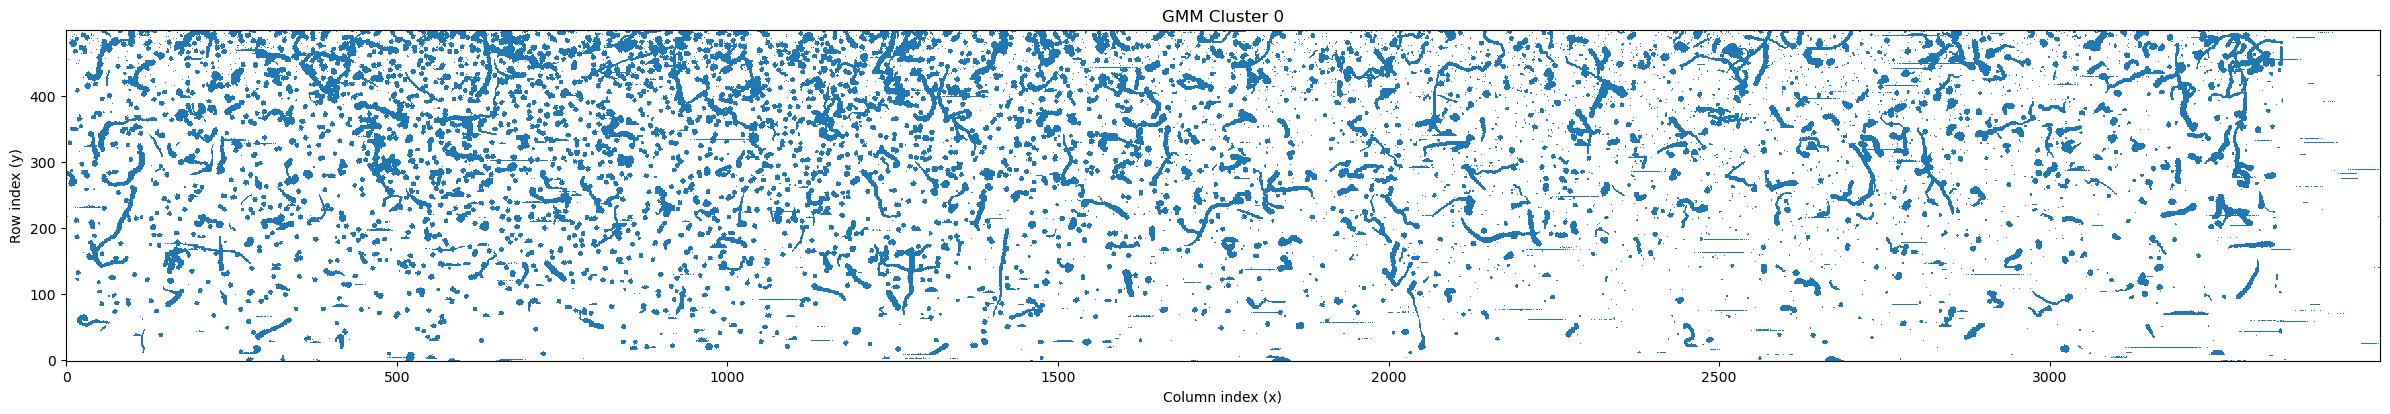

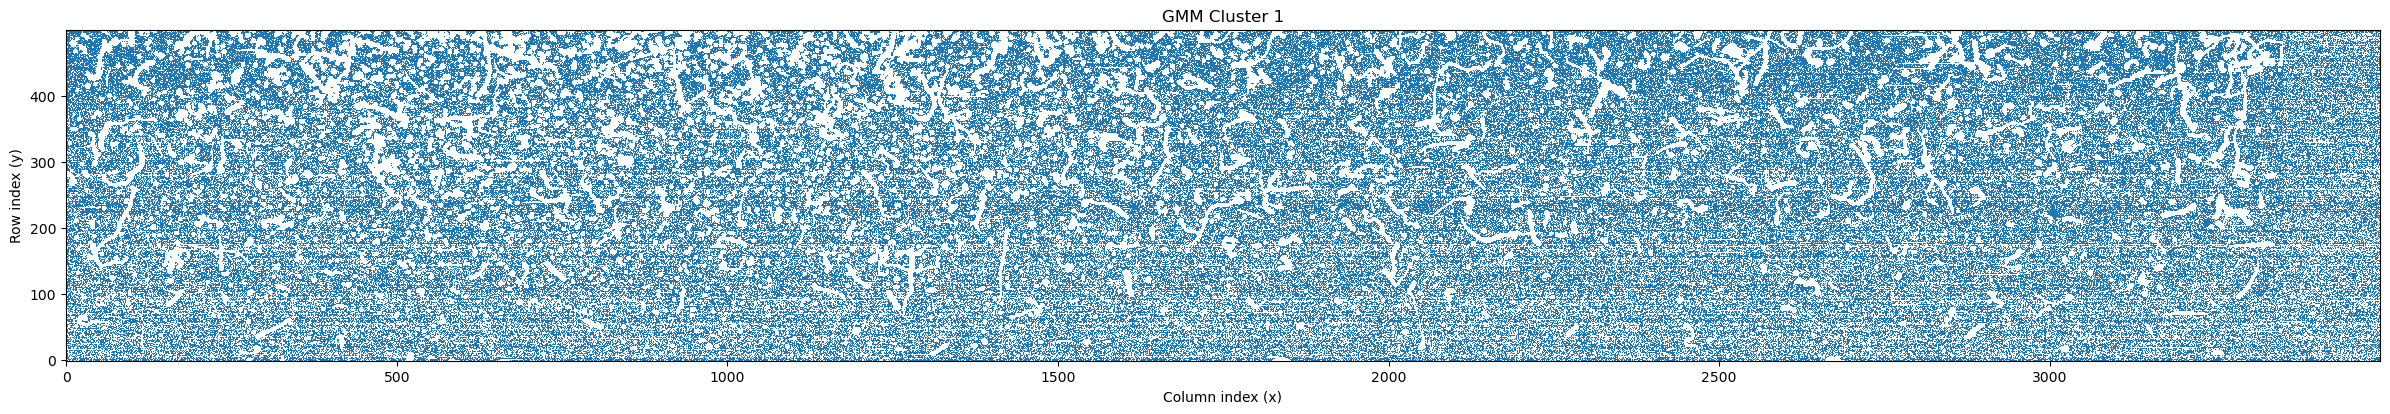

In [274]:
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=0)
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=1)


In [275]:
# # zoom into a specific region
# plot_clusters_on_frame(idx_yx, best, ccd_shape=cal_img.shape, clusters_to_show=[2],
#                         xlim=(0, 500), ylim=(300, 500), figsize=(24, 10))

In [276]:
# # zoom into a specific region
# plot_clusters_on_frame(idx_yx, best, ccd_shape=cal_img.shape, clusters_to_show=[1, 2, 0],
#                         xlim=(0, 500), ylim=(100, 300), figsize=(24, 10))

In [277]:
# plot_cluster_gallery_on_frame(idx_yx, best, ccd_shape=cal_img.shape)

In [297]:
blobs, labeled = blobs_from_gmm(
    X_raw=X_raw_cut,
    gmm_labels=best["labels"],
    frame_size=cal_img.shape,
    cluster_id=0
)

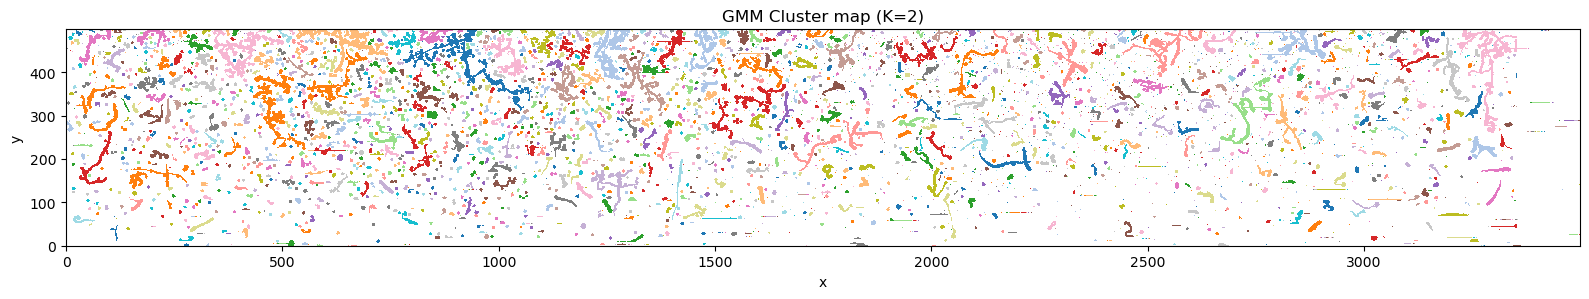

In [298]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(blobs)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(16, 10))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("GMM Cluster map (K=2)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


In [299]:
# how many blobs
print("Number of blobs:", len(blobs))

# pick a blob ID (e.g. first one)
bid = list(blobs.keys())[0]

blob = blobs[bid]
print(f"Blob {bid} has {len(blob)} pixels")
print("First 10 pixels [y, x, E]:")
print(blob[:10])

Number of blobs: 5677
Blob 1 has 54 pixels
First 10 pixels [y, x, E]:
[[0.00000000e+00 2.72000000e+02 3.72870471e-02]
 [0.00000000e+00 2.73000000e+02 2.88491077e-02]
 [0.00000000e+00 2.74000000e+02 7.42468037e-02]
 [0.00000000e+00 2.75000000e+02 8.47055411e-02]
 [0.00000000e+00 2.76000000e+02 1.03894066e-01]
 [0.00000000e+00 2.77000000e+02 1.41374426e-01]
 [0.00000000e+00 2.78000000e+02 1.49403045e-01]
 [0.00000000e+00 2.79000000e+02 1.18807110e-01]
 [0.00000000e+00 2.80000000e+02 7.02627323e-02]
 [0.00000000e+00 2.82000000e+02 2.26014832e-02]]


In [300]:
df_blobs = pd.DataFrame(
    {
        "blob_id": list(blobs.keys()),
        "points": list(blobs.values())
    }
)

In [301]:
df_blobs.head()

,blob_id,points
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273..."
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326...."
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381..."
3,4,"[[0.0, 383.0, 0.014797598166209645]]"
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514..."


In [302]:
df_blobs["cluster_size"] = df_blobs["points"].apply(len)

In [303]:
df_blobs.head()

,blob_id,points,cluster_size
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273...",54
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326....",39
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381...",2
3,4,"[[0.0, 383.0, 0.014797598166209645]]",1
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514...",159


In [304]:
df_blobs["energy"] = df_blobs["points"].apply(
    lambda pts: np.sum(np.asarray(pts)[:, 2])
)

In [305]:
df_blobs.head()

,blob_id,points,cluster_size,energy
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273...",54,5.037471
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326....",39,248.395053
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381...",2,0.037288
3,4,"[[0.0, 383.0, 0.014797598166209645]]",1,0.014798
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514...",159,65.735329


In [306]:
min_E = min(p[2] for pts in df_blobs["points"] for p in pts)
print(min_E)

0.012882938882421658


In [307]:

def weighted_std_xy(points):
    """
    points: array of shape (N,3) with columns [y, x, E]
    Returns: wSTD_y, wSTD_x
    """
    y = points[:, 0]
    x = points[:, 1]
    E = points[:, 2]

    Etot = E.sum()
    if Etot == 0:
        return np.nan, np.nan

    y_bar = np.sum(E * y) / Etot
    x_bar = np.sum(E * x) / Etot

    wSTD_y = np.sqrt(np.sum(E * (y - y_bar)**2) / Etot)
    wSTD_x = np.sqrt(np.sum(E * (x - x_bar)**2) / Etot)

    return wSTD_y, wSTD_x

In [308]:
df_blobs[["wSTD_y", "wSTD_x"]] = (
    df_blobs["points"]
    .apply(lambda pts: pd.Series(weighted_std_xy(pts)))
)

In [309]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273...",54,5.037471,1.184391,2.197259
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326....",39,248.395053,2.409261,0.948588
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381...",2,0.037288,0.000000,0.490768
3,4,"[[0.0, 383.0, 0.014797598166209645]]",1,0.014798,0.000000,0.000000
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514...",159,65.735329,3.269959,2.043559


In [310]:
df_blobs["wSTD_xy"] = np.sqrt(
    0.5 * (df_blobs["wSTD_x"]**2 + df_blobs["wSTD_y"]**2)
)

In [311]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x,wSTD_xy
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273...",54,5.037471,1.184391,2.197259,1.765040
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326....",39,248.395053,2.409261,0.948588,1.830896
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381...",2,0.037288,0.000000,0.490768,0.347025
3,4,"[[0.0, 383.0, 0.014797598166209645]]",1,0.014798,0.000000,0.000000,0.000000
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514...",159,65.735329,3.269959,2.043559,2.726606


lets make these plots!

1. Energy vs. wSTD_xy

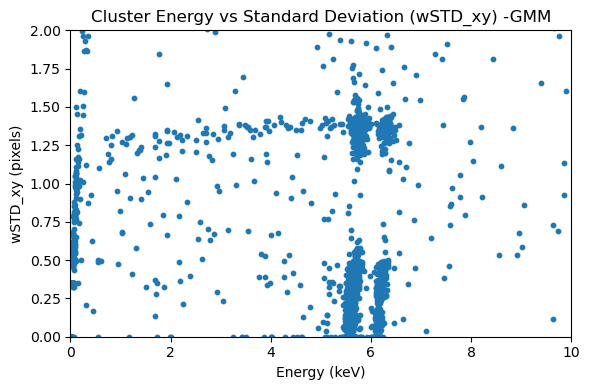

In [312]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["wSTD_xy"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.xlim(0,10)
plt.ylim(0,2)
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) -GMM")
plt.tight_layout()
plt.show()


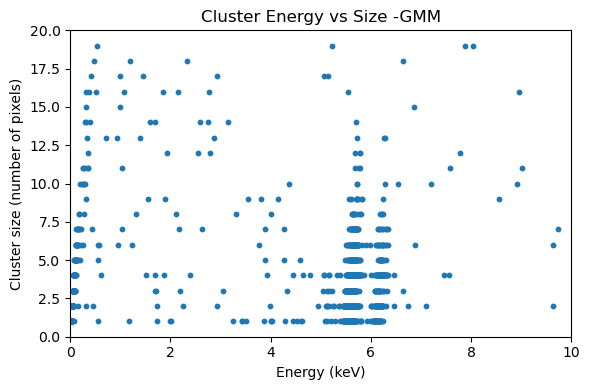

In [313]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["cluster_size"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size -GMM")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

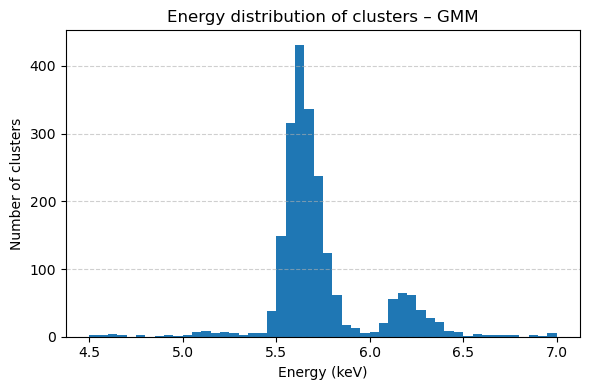

In [314]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(4.5, 7))

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – GMM")

ax = plt.gca()
ymax = int(ax.get_ylim()[1])

# --- y-axis ticks every 10 ---
ax.set_yticks(np.arange(0, ymax + 1, 100))

# --- grid only on major ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


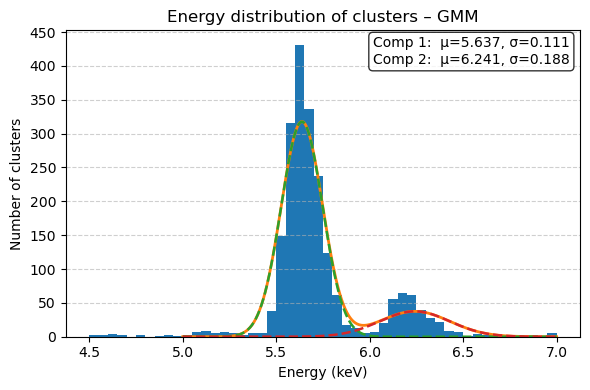

2-Gaussian mixture fit:
  Comp 1: weight=0.832947, mean=5.637485, std=0.110695
  Comp 2: weight=0.167053, mean=6.240691, std=0.188155


In [315]:
from scipy.stats import norm

# --- histogram settings (match your good histogram) ---
bins = 50
hist_range = (4.5, 7)

# --- fit range for the 2-Gaussian mixture ---
fit_min, fit_max = 5.0, 7.0

data = df_blobs["energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used for fitting ONLY (5–7 keV) ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]

# --- Fit 2-Gaussian mixture to UNBINNED data ---
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
gmm.fit(fit_data.reshape(-1, 1))

means = gmm.means_.ravel()
stds = np.sqrt(gmm.covariances_.ravel())
weights = gmm.weights_.ravel()

# sort components by mean (nice reporting/plotting)
order = np.argsort(means)
means, stds, weights = means[order], stds[order], weights[order]

# --- plot histogram (ALL data) exactly like before ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(data, bins=bins, range=hist_range)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – GMM")

# --- Overlay 2-Gaussian mixture ONLY over 5–7 keV ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 800)

pdf_components = [
    weights[k] * norm.pdf(x, loc=means[k], scale=stds[k])
    for k in range(2)
]
pdf_total = np.sum(pdf_components, axis=0)

# scale PDFs to histogram counts
scale = len(fit_data) * bin_width
y_total = pdf_total * scale
y_comps = [pc * scale for pc in pdf_components]

# plot total + components
plt.plot(x, y_total, linewidth=2)
plt.plot(x, y_comps[0], linestyle="--", linewidth=1.8)
plt.plot(x, y_comps[1], linestyle="--", linewidth=1.8)

# --- annotate fit ---
plt.text(
    0.98, 0.98,
    f"Comp 1:  μ={means[0]:.3f}, σ={stds[0]:.3f}\n"
    f"Comp 2:  μ={means[1]:.3f}, σ={stds[1]:.3f}",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- y-axis ticks every 50 (match your request) ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 50))

# --- grid aligned with those ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("2-Gaussian mixture fit:")
print(f"  Comp 1: weight={weights[0]:.6f}, mean={means[0]:.6f}, std={stds[0]:.6f}")
print(f"  Comp 2: weight={weights[1]:.6f}, mean={means[1]:.6f}, std={stds[1]:.6f}")

## Waders Comparison

In [316]:
import uproot

In [317]:
file = "/Users/salms/damicm-ml/img_8_stuff/sample1/panaSKImg_clustersRec_avg_Image_8_Low_Temp_106_20250923_093303_0_ext1.root"

In [318]:
f = uproot.open(file)
print(f.keys())

['clustersRec;1', 'info;1', 'process_config;1']


In [319]:
clustersRec_tree = f["clustersRec"]

In [320]:
df = clustersRec_tree.arrays(library="pd")

In [321]:
def expand_row_to_df(df, drop_cols=("RUNID", "Nclusters"), row_idx=0):
    """
    Expand a single row of `df` whose columns contain array-like entries
    into a long DataFrame, repeating scalar columns to match the array length.
    """
    row = df.iloc[row_idx]
    cols = [c for c in df.columns if c not in drop_cols]

    # Find target length from the first array-like column
    N = next((len(row[c]) for c in cols if hasattr(row[c], "__len__")), None)
    if N is None:
        raise ValueError("No array-like columns found to expand.")

    data = {
        c: list(row[c]) if hasattr(row[c], "__len__") else [row[c]] * N
        for c in cols
    }
    return pd.DataFrame(data).reset_index(drop=True)


df_expanded = expand_row_to_df(df)
print(df_expanded.shape)
df_expanded.head()

(3390, 56)


,DX,DY,Energy,Energy_AVG,Energy_PS,Npix,PosX,PosY,Qmax,QmaxX,...,readout_end,readout_start,seed_nsig_delta,seed_nsig_max,seed_nsig_min,seed_nsig_pixels,sigma_seed_eV,wSTD_X,wSTD_XY,wSTD_Y
0,16.0,7.0,5.249293,-1407.477905,1866.727173,77,278.286835,2.737540,0.288491,278.0,...,1.758643e+09,1.758613e+09,405.323029,415.400482,10.077470,"[10.176284, 11.486744, 53.68999, 41.54012, 106...",0.694488,2.424870,1.928515,1.248339
1,8.0,9.0,248.410278,86595.445312,88338.414062,41,328.515747,4.721443,20.910187,329.0,...,1.758643e+09,1.758613e+09,30098.103516,30108.787109,10.683082,"[155.24089, 3276.4075, 8332.5, 9495.433, 4694....",0.694488,0.948796,1.830961,2.409278
2,2.0,2.0,5.709201,1902.084717,2030.277344,3,1965.964233,415.003204,5.486501,1966.0,...,1.758643e+09,1.758613e+09,7873.755371,7900.067383,26.312252,"[294.35556, 7900.0674, 26.312252]",0.694488,0.185807,0.137322,0.056484
3,11.0,4.0,0.323033,-1076.317993,114.875412,28,382.142700,2.407837,0.026439,383.0,...,1.758643e+09,1.758613e+09,27.892502,38.069534,10.177032,"[10.648304, 16.256544, 21.710821, 31.981056, 1...",0.694488,2.654646,2.026502,1.079944
4,20.0,14.0,65.885292,15908.962891,23429.794922,177,520.551270,5.214506,1.760694,520.0,...,1.758643e+09,1.758613e+09,2524.719727,2535.240723,10.520967,"[42.810978, 143.88213, 409.95505, 906.4774, 17...",0.694488,2.066094,2.735051,3.269903


In [322]:
min_E_2 = min(e for arr in df_expanded["pixels_E"] for e in arr)
print(min_E_2)

0.0069449027


In [323]:
df_expanded.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DX                  3390 non-null   float32
 1   DY                  3390 non-null   float32
 2   Energy              3390 non-null   float32
 3   Energy_AVG          3390 non-null   float32
 4   Energy_PS           3390 non-null   float32
 5   Npix                3390 non-null   int32  
 6   PosX                3390 non-null   float32
 7   PosY                3390 non-null   float32
 8   Qmax                3390 non-null   float32
 9   QmaxX               3390 non-null   float32
 10  QmaxY               3390 non-null   float32
 11  RMSX                3390 non-null   float32
 12  RMSY                3390 non-null   float32
 13  STD_X               3390 non-null   float32
 14  STD_XY              3390 non-null   float32
 15  STD_Y               3390 non-null   float32
 16  closest_cls_dist 

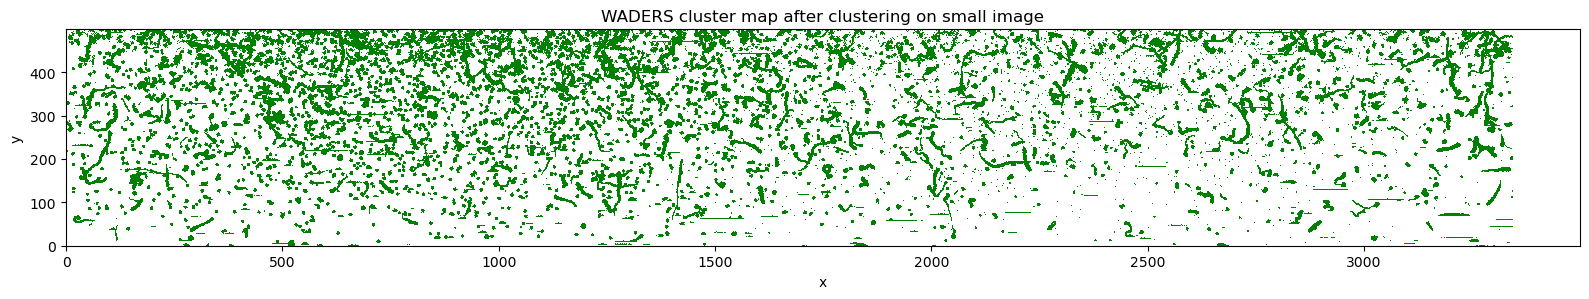

In [324]:
H, W = cal_img.shape
img = np.zeros((H, W), dtype=int)

for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = 1   # mark cluster pixels

# custom colormap: 0 -> white, 1 -> green
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(16, 10))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map after clustering on small image")
plt.tight_layout()
plt.show()


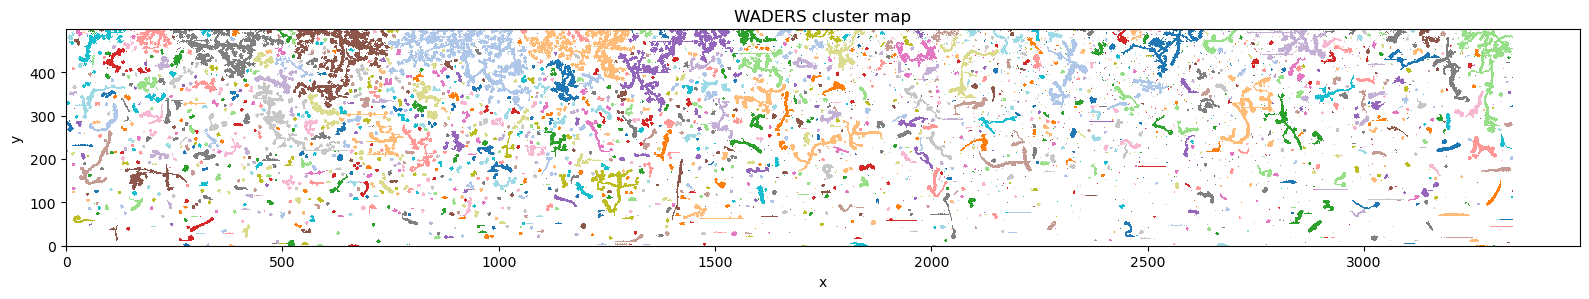

In [325]:
from matplotlib.colors import ListedColormap

H, W = cal_img.shape
img = np.zeros((H, W), dtype=int)

# assign a unique label to each cluster (starting from 1)
for label, (_, row) in enumerate(df_expanded.iterrows(), start=1):
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = label

# build a colormap: 0 = white, clusters = tab20 colors
n_clusters = len(df_expanded)
colors = ["white"] + list(plt.cm.tab20.colors) * ((n_clusters // 20) + 1)
cmap = ListedColormap(colors[: n_clusters + 1])

plt.figure(figsize=(16, 10))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map")
plt.tight_layout()
plt.show()


In [326]:
len(df_expanded)

3390

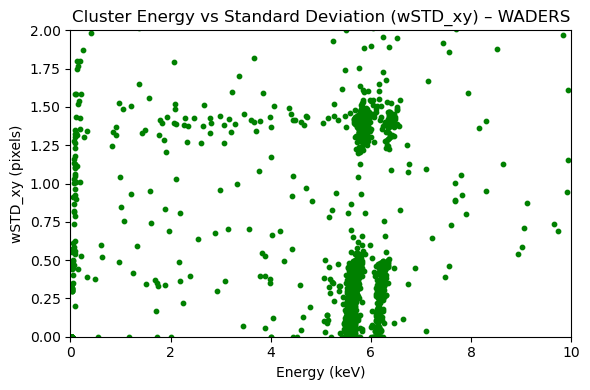

In [327]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["wSTD_XY"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) – WADERS")
plt.xlim(0,10)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

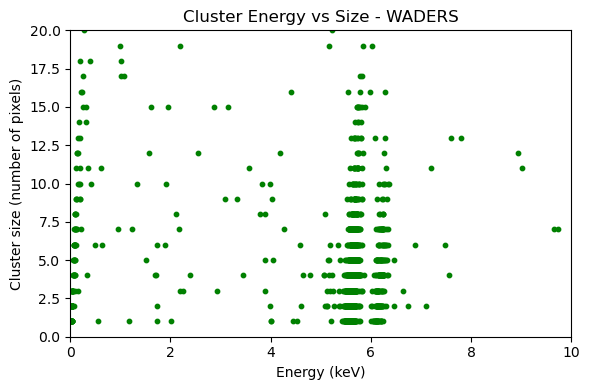

In [328]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["Npix"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size - WADERS")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

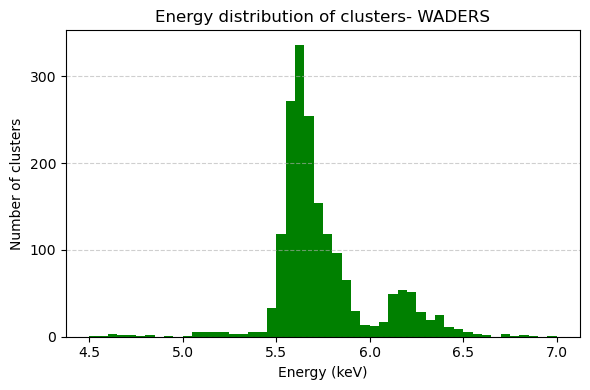

In [329]:
plt.figure(figsize=(6, 4))
plt.hist(df_expanded["Energy"], bins=50, color="green", range=(4.5, 7))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- WADERS")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 100))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

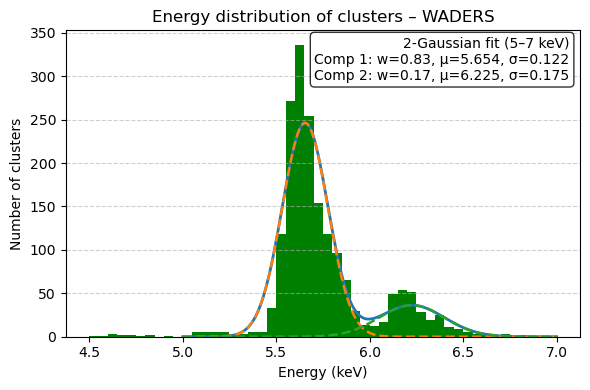

2-Gaussian mixture fit (5–7 keV):
  Comp 1: weight=0.825440, mean=5.654328, std=0.122002
  Comp 2: weight=0.174560, mean=6.224984, std=0.174941


In [330]:
# --- settings ---
bins = 50
hist_range = (4.5, 7)
fit_min, fit_max = 5.0, 7.0   # fit 2 Gaussians only in this window

# --- extract energy ---
data = df_expanded["Energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used ONLY for mixture fit ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]

# --- Fit 2-Gaussian mixture to UNBINNED data in 5–7 keV ---
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
gmm.fit(fit_data.reshape(-1, 1))

means = gmm.means_.ravel()
stds = np.sqrt(gmm.covariances_.ravel())
weights = gmm.weights_.ravel()

# sort by mean for nicer reporting/plotting
order = np.argsort(means)
means, stds, weights = means[order], stds[order], weights[order]

# --- plot histogram ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(
    data, bins=bins, color="green", range=hist_range
)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – WADERS")

# --- overlay 2-Gaussian mixture ONLY over 5–7 keV ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 800)

pdf_components = [
    weights[k] * norm.pdf(x, loc=means[k], scale=stds[k])
    for k in range(2)
]
pdf_total = np.sum(pdf_components, axis=0)

scale = len(fit_data) * bin_width
y_total = pdf_total * scale
y_comps = [pc * scale for pc in pdf_components]

plt.plot(x, y_total, linewidth=2)
plt.plot(x, y_comps[0], linestyle="--", linewidth=1.8)
plt.plot(x, y_comps[1], linestyle="--", linewidth=1.8)

# --- annotate fit ---
plt.text(
    0.98, 0.98,
    "2-Gaussian fit (5–7 keV)\n"
    f"Comp 1: w={weights[0]:.2f}, μ={means[0]:.3f}, σ={stds[0]:.3f}\n"
    f"Comp 2: w={weights[1]:.2f}, μ={means[1]:.3f}, σ={stds[1]:.3f}",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- y-axis ticks in chunks of 50 ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 50))

# --- grid aligned with those ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("2-Gaussian mixture fit (5–7 keV):")
print(f"  Comp 1: weight={weights[0]:.6f}, mean={means[0]:.6f}, std={stds[0]:.6f}")
print(f"  Comp 2: weight={weights[1]:.6f}, mean={means[1]:.6f}, std={stds[1]:.6f}")

In [331]:
H, W = cal_img.shape

# --- GMM mask from df_blobs["points"] which stores [y,x,E] arrays ---
gmm_mask = np.zeros((H, W), dtype=bool)
for pts in df_blobs["points"]:
    pts = np.asarray(pts)
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)
    gmm_mask[ys, xs] = True

# --- WADERS mask from df_expanded pixels_x/pixels_y (1-based -> convert to 0-based) ---
waders_mask = np.zeros((H, W), dtype=bool)
for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    waders_mask[ys, xs] = True

overlap_mask = gmm_mask & waders_mask

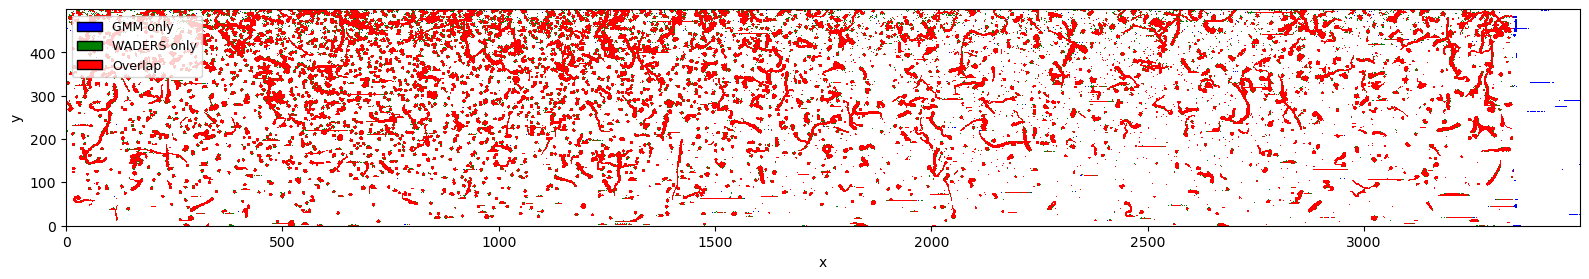

In [332]:
from matplotlib.patches import Patch

overlay = np.zeros((H, W), dtype=int)
overlay[gmm_mask & ~waders_mask] = 1
overlay[waders_mask & ~gmm_mask] = 2
overlay[overlap_mask] = 3

cmap_overlay = ListedColormap(["white", "blue", "green", "red"])

plt.figure(figsize=(16, 10))
plt.imshow(overlay, origin="lower", cmap=cmap_overlay, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")

# --- legend ---
legend_elements = [
    Patch(facecolor="blue",  edgecolor="black", label="GMM only"),
    Patch(facecolor="green", edgecolor="black", label="WADERS only"),
    Patch(facecolor="red",   edgecolor="black", label="Overlap"),
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()


WADERs in window: 1495
GMM in window:    1735
Matched: 1489
WADERs-only: 6
GMM-only:    246


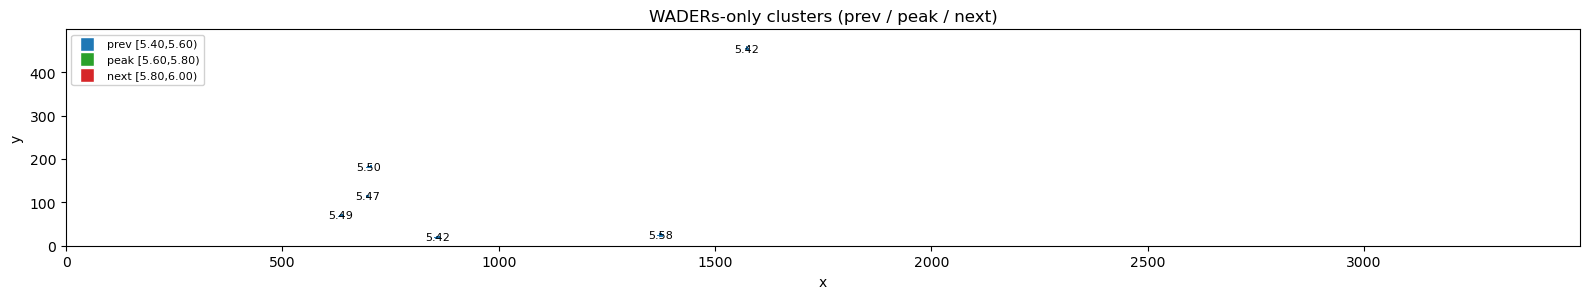

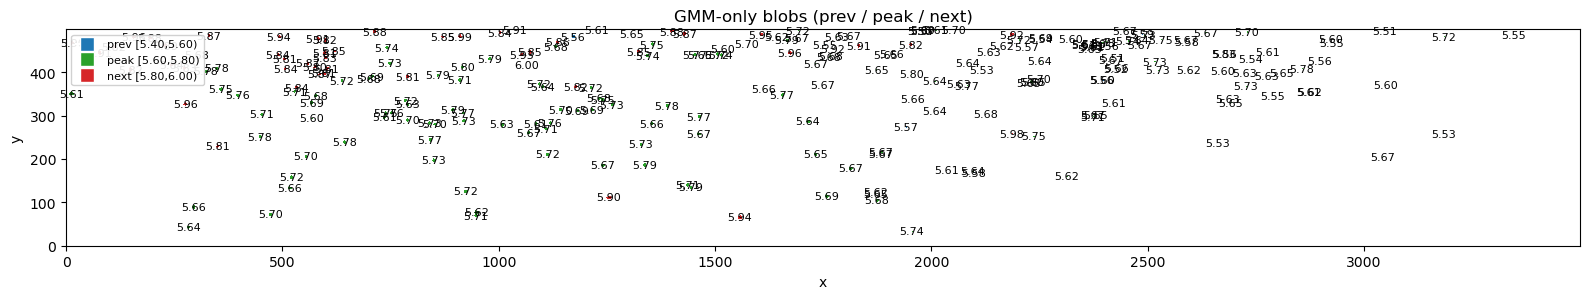

In [333]:
# -------------------------------
# 0) manual bins (same as you use)
# -------------------------------
peak_lo, peak_hi = 5.6, 5.8
bin_width = peak_hi - peak_lo
prev_lo, prev_hi = peak_lo - bin_width, peak_lo
next_lo, next_hi = peak_hi, peak_hi + bin_width
Emin, Emax = prev_lo, next_hi

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

# -------------------------------
# 1) extract clusters (pixels + centroid) for both methods
# -------------------------------
def extract_waders(df_expanded):
    out = []
    dfW = df_expanded[df_expanded["Energy"].between(Emin, Emax, inclusive="left")]
    for idx, row in dfW.iterrows():
        E = float(row["Energy"])
        c = class_from_energy(E)
        if c is None:
            continue
        xs = np.asarray(row["pixels_x"], dtype=int)
        ys = np.asarray(row["pixels_y"], dtype=int)
        if xs.size == 0:
            continue
        out.append({
            "id": idx,
            "E": E,
            "c": c,
            "xs": xs,
            "ys": ys,
            "cx": xs.mean(),
            "cy": ys.mean()
        })
    return out

def extract_gmm(df_blobs):
    out = []
    dfG = df_blobs[df_blobs["energy"].between(Emin, Emax, inclusive="left")]
    for idx, row in dfG.iterrows():
        E = float(row["energy"])
        c = class_from_energy(E)
        if c is None:
            continue
        pts = np.asarray(row["points"], dtype=float)  # [y, x, Epix]
        ys = pts[:, 0].astype(int)
        xs = pts[:, 1].astype(int)
        if xs.size == 0:
            continue
        out.append({
            "id": idx,
            "E": E,
            "c": c,
            "xs": xs,
            "ys": ys,
            "cx": xs.mean(),
            "cy": ys.mean()
        })
    return out

W_clusters = extract_waders(df_expanded)
G_clusters = extract_gmm(df_blobs)

print("WADERs in window:", len(W_clusters))
print("GMM in window:   ", len(G_clusters))

# -------------------------------
# 2) 1-to-1 matching by centroid distance
# -------------------------------
tol_px = 6.0      # tune if needed (try 6-10)
dE = None         # set to e.g. 0.05 if you want energy gating

cands = []  # (dist, wi, gi)
for wi, w in enumerate(W_clusters):
    for gi, g in enumerate(G_clusters):
        if dE is not None and abs(w["E"] - g["E"]) > dE:
            continue
        dist = np.hypot(w["cx"] - g["cx"], w["cy"] - g["cy"])
        if dist <= tol_px:
            cands.append((dist, wi, gi))

cands.sort(key=lambda t: t[0])

W_used = set()
G_used = set()
W_to_G = {}  # wi -> gi

for dist, wi, gi in cands:
    if wi in W_used or gi in G_used:
        continue
    W_used.add(wi)
    G_used.add(gi)
    W_to_G[wi] = gi

W_only = [W_clusters[i] for i in range(len(W_clusters)) if i not in W_used]
G_only = [G_clusters[i] for i in range(len(G_clusters)) if i not in G_used]

print("Matched:", len(W_to_G))
print("WADERs-only:", len(W_only))
print("GMM-only:   ", len(G_only))

# -------------------------------
# 3) make "only" label images
# -------------------------------
H, W = cal_img.shape

def make_rgb_from_only(clusters_only, title):
    cls = np.full((H, W), -1, dtype=np.int8)
    centroids = []

    for obj in clusters_only:
        xs = obj["xs"].astype(int)
        ys = obj["ys"].astype(int)

        m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        xs, ys = xs[m], ys[m]
        if xs.size == 0:
            continue

        cls[ys, xs] = obj["c"]
        centroids.append((xs.mean(), ys.mean(), obj["E"]))

    rgb = np.ones((H, W, 3), dtype=float)
    rgb[cls == 0] = (0.12, 0.47, 0.71)  # prev
    rgb[cls == 1] = (0.17, 0.63, 0.17)  # peak
    rgb[cls == 2] = (0.84, 0.15, 0.16)  # next

    plt.figure(figsize=(16, 10))
    plt.imshow(rgb, origin="lower", interpolation="none")

    for cx, cy, E in centroids:
        plt.text(cx, cy, f"{E:.2f}", ha="center", va="center", fontsize=8, color="black")

    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")

    plt.legend(
        handles=[
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.12,0.47,0.71), markersize=10,
                       label=f"prev [{prev_lo:.2f},{prev_hi:.2f})"),
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.17,0.63,0.17), markersize=10,
                       label=f"peak [{peak_lo:.2f},{peak_hi:.2f})"),
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.84,0.15,0.16), markersize=10,
                       label=f"next [{next_lo:.2f},{next_hi:.2f})"),
        ],
        loc="upper left",
        fontsize=8,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()

# -------------------------------
# 4) plot symmetric difference views
# -------------------------------
make_rgb_from_only(W_only, "WADERs-only clusters (prev / peak / next)")
make_rgb_from_only(G_only, "GMM-only blobs (prev / peak / next)")

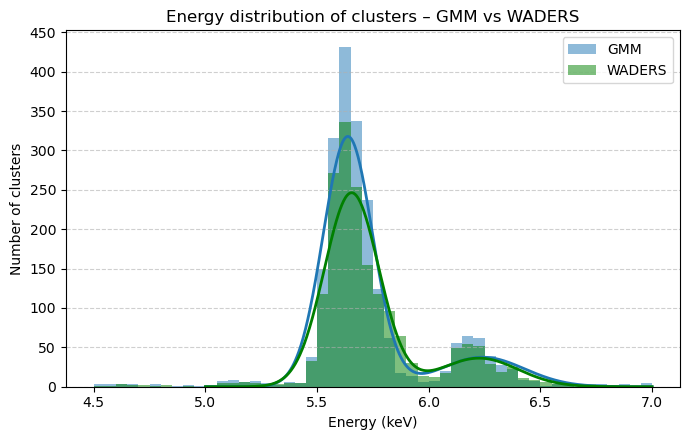

In [335]:
bins = 50
hist_range = (4.5, 7)
fit_min, fit_max = 5.0, 7.0

def get_data_and_fit(series):
    data = series.to_numpy(dtype=float)
    data = data[np.isfinite(data)]
    fit_data = data[(data >= fit_min) & (data <= fit_max)]
    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
    gmm.fit(fit_data.reshape(-1, 1))
    means = gmm.means_.ravel()
    stds = np.sqrt(gmm.covariances_.ravel())
    weights = gmm.weights_.ravel()
    order = np.argsort(means)
    return data, fit_data, means[order], stds[order], weights[order]

gmm_data,  gmm_fit,  g_means, g_stds, g_w = get_data_and_fit(df_blobs["energy"])
wad_data,  wad_fit,  w_means, w_stds, w_w = get_data_and_fit(df_expanded["Energy"])

plt.figure(figsize=(7, 4.5))

# shared bin edges so both histograms line up exactly
bin_edges = np.linspace(hist_range[0], hist_range[1], bins + 1)
bin_width = bin_edges[1] - bin_edges[0]

plt.hist(gmm_data, bins=bin_edges, color="tab:blue",  alpha=0.5, label="GMM")
plt.hist(wad_data, bins=bin_edges, color="green",     alpha=0.5, label="WADERS")

x = np.linspace(fit_min, fit_max, 800)

def overlay_fit(means, stds, weights, n_fit, color):
    pdf = sum(weights[k] * norm.pdf(x, means[k], stds[k]) for k in range(2))
    plt.plot(x, pdf * n_fit * bin_width, color=color, linewidth=2)

overlay_fit(g_means, g_stds, g_w, len(gmm_fit), "tab:blue")
overlay_fit(w_means, w_stds, w_w, len(wad_fit), "green")

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – GMM vs WADERS")
plt.legend()

ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 50))
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()